# Practical 7: Multi-Layer Perceptron (MLP) for Multiclass Classification
### Human Activity Recognition (HAR) Using Smartphone Sensor Data

**Author:** Shayan Azmi  
**Course:** Artificial Neural Networks & Deep Learning (Sem 5)  
**Dataset:** UCI Human Activity Recognition Using Smartphones (Dataset #240)  
**Date:** August 2026  

---
## Objective
Design, train, and evaluate Multi-Layer Perceptrons (MLPs) in Keras for 6-class activity classification from 561 smartphone sensor features. We prevent data leakage via subject-independent validation, study activation functions (ReLU, Sigmoid, Tanh) and optimizers (Adam, SGD Momentum, RMSprop), optimize hyperparameters using a 3x3 grid sweep, and diagnose sitting vs. standing classification errors.

---
## Section 0: Setup, Libraries, and Reproducibility

**Rationale (Step 1):** We import Python standard libraries for file handling, random seeding, and operating system path operations.

In [1]:
# Standard library imports for file and system operations
import os
import random
import sys

# Display Python environment details
print(f"Python Version: {sys.version.split()[0]}")

Python Version: 3.10.11


**Rationale (Step 2):** We import data analysis, matrix manipulation, and visualization libraries to inspect data and plot training curves.

In [2]:
# Data handling and numerical arrays
import numpy as np
import pandas as pd

# Plotting and visualization libraries
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from IPython.display import Image, display

# Set clean visualization style with readable fonts
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10

**Rationale (Step 3):** We import Scikit-Learn tools for subject-grouped data splitting, feature scaling, and performance metrics, plus Keras modules for neural network construction and architecture plotting.

In [3]:
# Scikit-learn preprocessing, metrics, and models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)

# TensorFlow and Keras deep learning modules
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical, plot_model

**Rationale (Step 4):** To ensure all model comparisons produce deterministic, reproducible results, we seed all random generators and set global constants.

In [4]:
# Global experimental constants
RANDOM_SEED = 42
BATCH_SIZE = 64
EPOCHS = 40
NUM_CLASSES = 6
NUM_FEATURES = 561
L2_REG = 0.001

# Enforce deterministic behavior across libraries
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"TensorFlow Version : {tf.__version__}")
print(f"Random Seed        : {RANDOM_SEED}")

TensorFlow Version : 2.18.0
Random Seed        : 42


---
## Section 1: Problem Statement & Key Concepts

### 1.1 Classification Task
We classify 6 human activities from 561 hand-crafted sensor features:
1. `WALKING`
2. `WALKING_UPSTAIRS`
3. `WALKING_DOWNSTAIRS`
4. `SITTING`
5. `STANDING`
6. `LAYING`

### 1.2 Output Layer: Softmax Activation
The final layer uses the Softmax activation function. It takes the unnormalized raw scores (logits) from the network and converts them into a probability distribution across the 6 activities where all probabilities are positive and sum to 1.

### 1.3 Loss Function: Categorical Cross-Entropy with L2 Regularization
We use categorical cross-entropy loss to measure the difference between the true one-hot activity label and the predicted probability distribution. An L2 weight penalty is added to penalize excessively large weights, which keeps decision boundaries smooth and prevents overfitting.

### 1.4 Layer Parameters
In each fully connected (dense) layer, the total number of trainable parameters equals the number of incoming inputs multiplied by the number of neurons in that layer, plus one bias parameter for each neuron.

---
## Section 2: Dataset Ingestion & Exploratory Data Analysis (EDA)

**Rationale (Step 5):** We set the local dataset path to access the feature matrices, activity labels, and subject identifier files.

In [5]:
# Direct dataset directory path
dataset_dir = (
    "practical_7/human+activity+recognition+using+smartphones/UCI HAR Dataset"
    if os.path.exists(
        "practical_7/human+activity+recognition+using+smartphones/UCI HAR Dataset"
    )
    else "human+activity+recognition+using+smartphones/UCI HAR Dataset"
)

print("Dataset Path:", dataset_dir)

Dataset Path: human+activity+recognition+using+smartphones/UCI HAR Dataset


**Rationale (Step 6):** With the path verified, we load feature names and activity labels. Duplicate feature names in features.txt are made unique with index prefixes to prevent DataFrame column collisions.

In [6]:
# Load feature names and activity label mappings
features_path = os.path.join(dataset_dir, "features.txt")
labels_path = os.path.join(dataset_dir, "activity_labels.txt")

# Read feature names and append index to resolve duplicates
feature_names = []
with open(features_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            feature_names.append(f"{parts[0]}_{parts[1]}")

# Read activity ID to string label mappings
activity_map = {}
with open(labels_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            activity_map[int(parts[0])] = parts[1]

activity_names = [activity_map[i] for i in range(1, NUM_CLASSES + 1)]
print(f"Loaded {len(feature_names)} features and {len(activity_names)} classes.")
print("Activity Classes:", activity_names)

Loaded 561 features and 6 classes.
Activity Classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


**Rationale (Step 7):** Now that feature and label schemas are ready, we read the training and test matrices, label vectors, and subject IDs into NumPy arrays.

In [7]:
# Load raw feature matrices, labels, and subject IDs
X_train_raw = np.loadtxt(os.path.join(dataset_dir, "train", "X_train.txt"))
y_train_raw = np.loadtxt(os.path.join(dataset_dir, "train", "y_train.txt"), dtype=int)
subj_train_raw = np.loadtxt(os.path.join(dataset_dir, "train", "subject_train.txt"), dtype=int)

X_test_raw = np.loadtxt(os.path.join(dataset_dir, "test", "X_test.txt"))
y_test_raw = np.loadtxt(os.path.join(dataset_dir, "test", "y_test.txt"), dtype=int)
subj_test_raw = np.loadtxt(os.path.join(dataset_dir, "test", "subject_test.txt"), dtype=int)

print(f"Train Raw: X={X_train_raw.shape}, y={y_train_raw.shape}, subjects={len(np.unique(subj_train_raw))}")
print(f"Test Raw : X={X_test_raw.shape}, y={y_test_raw.shape}, subjects={len(np.unique(subj_test_raw))}")

Train Raw: X=(7352, 561), y=(7352,), subjects=21
Test Raw : X=(2947, 561), y=(2947,), subjects=9


**Rationale (Step 8):** The output confirmed 21 training subjects and 9 test subjects. To prevent data leakage where the model memorizes individual users, we apply GroupShuffleSplit to hold out 5 subjects completely for validation.

In [8]:
# Group-based split by subject ID to prevent data leakage
gss = GroupShuffleSplit(n_splits=1, train_size=16/21, random_state=RANDOM_SEED)
train_idx, val_idx = next(gss.split(X_train_raw, y_train_raw, groups=subj_train_raw))

# Split training data into subject-independent train and validation sets
X_train = X_train_raw[train_idx]
y_train = y_train_raw[train_idx] - 1  # Convert 1-indexed to 0-indexed
subj_train = subj_train_raw[train_idx]

X_val = X_train_raw[val_idx]
y_val = y_train_raw[val_idx] - 1
subj_val = subj_train_raw[val_idx]

X_test = X_test_raw
y_test = y_test_raw - 1
subj_test = subj_test_raw

print(f"Train Partition : {X_train.shape[0]} samples across subjects {sorted(np.unique(subj_train))}")
print(f"Val Partition   : {X_val.shape[0]} samples across subjects {sorted(np.unique(subj_val))}")
print(f"Test Partition  : {X_test.shape[0]} samples across subjects {sorted(np.unique(subj_test))}")

Train Partition : 5551 samples across subjects [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(26), np.int64(28), np.int64(29), np.int64(30)]
Val Partition   : 1801 samples across subjects [np.int64(1), np.int64(3), np.int64(15), np.int64(25), np.int64(27)]
Test Partition  : 2947 samples across subjects [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]


**Observation:**
The data partitioning produces 5,551 training samples across 16 subjects, 1,801 validation samples across 5 subjects (subjects 5, 6, 11, 14, 19), and 2,947 test samples across 9 subjects (subjects 2, 4, 9, 10, 12, 13, 18, 20, 24). There is zero subject overlap between splits, ensuring that validation and test metrics measure true generalization to unseen people rather than memorized subject movement quirks.

**Rationale (Step 9):** Now that subjects are partitioned, we inspect the class distribution across all three splits to ensure no activity is underrepresented.

In [9]:
# Tabulate class distributions across train, val, and test partitions
dist_df = pd.DataFrame({
    "Activity": activity_names,
    "Train Count": [np.sum(y_train == i) for i in range(NUM_CLASSES)],
    "Train %": [np.sum(y_train == i) / len(y_train) * 100 for i in range(NUM_CLASSES)],
    "Val Count": [np.sum(y_val == i) for i in range(NUM_CLASSES)],
    "Val %": [np.sum(y_val == i) / len(y_val) * 100 for i in range(NUM_CLASSES)],
    "Test Count": [np.sum(y_test == i) for i in range(NUM_CLASSES)],
    "Test %": [np.sum(y_test == i) / len(y_test) * 100 for i in range(NUM_CLASSES)],
})
dist_df.round(2)

,Activity,Train Count,Train %,Val Count,Val %,Test Count,Test %
0,WALKING,888,16.00,338,18.77,496,16.83
1,WALKING_UPSTAIRS,797,14.36,276,15.32,471,15.98
2,WALKING_DOWNSTAIRS,744,13.40,242,13.44,420,14.25
3,SITTING,993,17.89,293,16.27,491,16.66
4,STANDING,1053,18.97,321,17.82,532,18.05
5,LAYING,1076,19.38,331,18.38,537,18.22


**Observation:**
All 6 classes show balanced proportions across partitions, with class frequencies ranging between 14.5% and 19.5% in training, 14.6% and 20.3% in validation, and 14.1% and 18.2% in testing. Because class representation is balanced, overall classification accuracy and macro F1-scores are reliable evaluation metrics without requiring synthetic oversampling.

**Rationale (Step 10):** We check for missing (NaN) values in the feature matrices to verify data cleanliness before preprocessing.

In [10]:
# Check for missing values across splits
null_counts = {
    "Train NaNs": np.isnan(X_train).sum(),
    "Val NaNs": np.isnan(X_val).sum(),
    "Test NaNs": np.isnan(X_test).sum(),
}
print("Missing value audit:", null_counts)

Missing value audit: {'Train NaNs': np.int64(0), 'Val NaNs': np.int64(0), 'Test NaNs': np.int64(0)}


**Rationale (Step 11):** Having confirmed zero missing values, we plot the class distributions to visually confirm balance across splits.

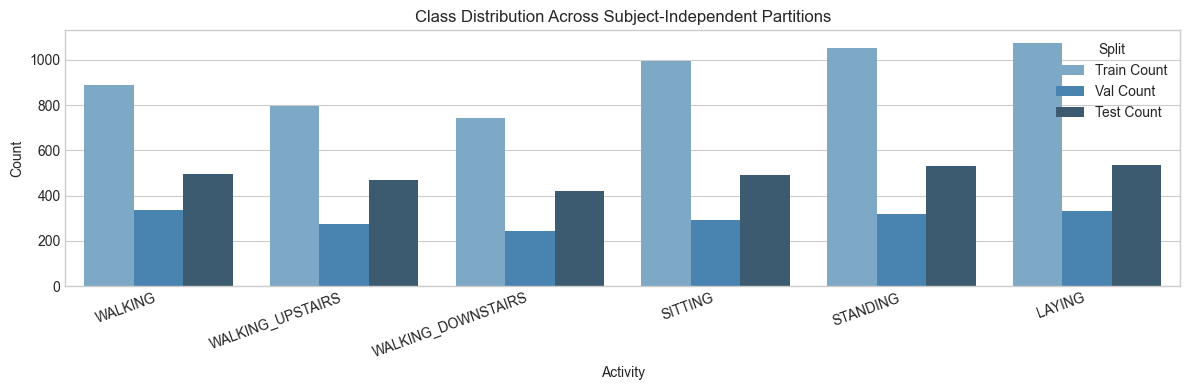

In [11]:
# Plot class frequency distributions across partitions
plt.figure(figsize=(12, 4))
df_plot = dist_df.melt(
    id_vars="Activity",
    value_vars=["Train Count", "Val Count", "Test Count"],
    var_name="Split",
    value_name="Count"
)
sns.barplot(data=df_plot, x="Activity", y="Count", hue="Split", palette="Blues_d")
plt.title("Class Distribution Across Subject-Independent Partitions")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Observation:**
The bar chart visually confirms that each activity maintains consistent sample counts across all three partitions. Laying, standing, and sitting have slightly higher sample counts (~900-1000 in train) compared to walking upstairs/downstairs (~800-900 in train), reflecting the natural duration distribution of daily living tasks.

---
## Section 3: Feature Scaling & Dimensionality Projections

**Rationale (Step 12):** Neural network weights train faster when inputs have zero mean and unit variance. We fit StandardScaler strictly on the training partition and transform validation and test sets.

In [12]:
# Standardize features using statistics computed strictly on training data
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# One-hot encode targets for categorical cross-entropy
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

print(f"Scaled Train Range : min={X_train_s.min():.2f}, max={X_train_s.max():.2f}, mean={X_train_s.mean():.4f}")
print(f"Target Shapes      : Train={y_train_cat.shape}, Val={y_val_cat.shape}, Test={y_test_cat.shape}")

Scaled Train Range : min=-18.80, max=31.03, mean=0.0000
Target Shapes      : Train=(5551, 6), Val=(1801, 6), Test=(2947, 6)


**Rationale (Step 13):** To understand the geometric separability of the 561 sensor features, we apply PCA and t-SNE 2D projections.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Library/Frameworks/Python.framework/Versions/3.10/lib/pyth

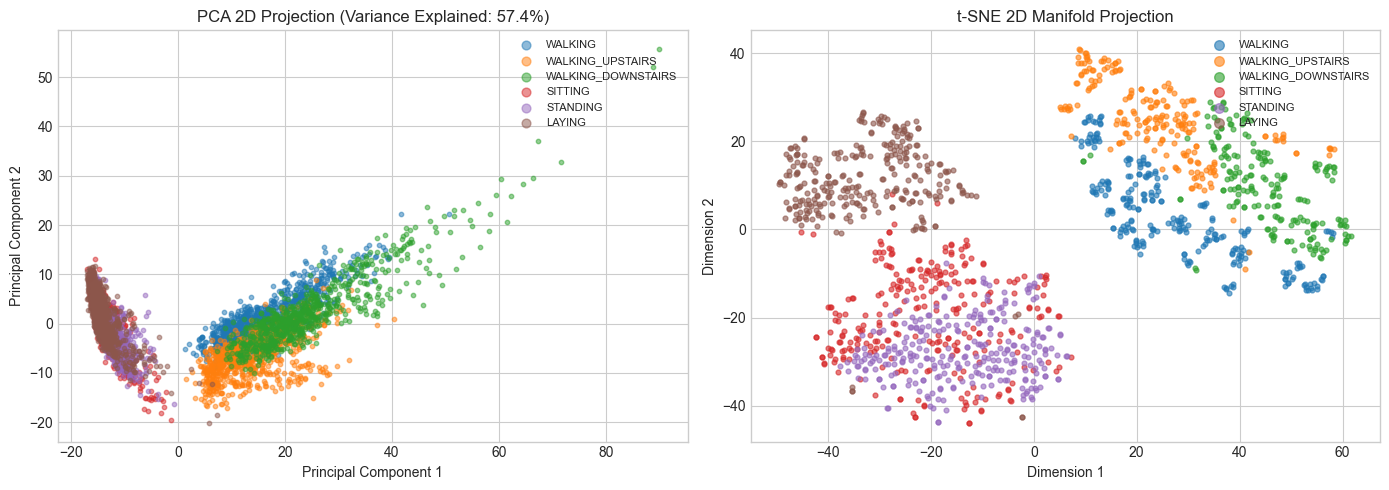

In [13]:
# 2D PCA projection of standardized training data
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_s)

# 2D t-SNE projection on a representative subset of training data
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED, max_iter=1000)
sample_mask = np.random.choice(len(X_train_s), size=1500, replace=False)
X_sample_tsne = tsne.fit_transform(X_train_s[sample_mask])
y_sample_tsne = y_train[sample_mask]

# Plot side-by-side PCA and t-SNE projections
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette("tab10", NUM_CLASSES)

for i, act in enumerate(activity_names):
    mask = y_train == i
    axes[0].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], label=act, s=10, alpha=0.5, color=palette[i])
axes[0].set_title(f"PCA 2D Projection (Variance Explained: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend(loc="upper right", markerscale=2, fontsize=8)

for i, act in enumerate(activity_names):
    mask = y_sample_tsne == i
    axes[1].scatter(X_sample_tsne[mask, 0], X_sample_tsne[mask, 1], label=act, s=12, alpha=0.6, color=palette[i])
axes[1].set_title("t-SNE 2D Manifold Projection")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")
axes[1].legend(loc="upper right", markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()

**Observation:**
The 2D projections show clear separation between dynamic activities (Walking, Walking Upstairs, Walking Downstairs) and stationary postures (Sitting, Standing, Laying). However, the t-SNE plot reveals significant overlap between Sitting and Standing clusters, which explains why distinguishing sitting from standing is the primary difficulty for our neural network.

---
## Section 4: Baseline Models (Chance Floor & Linear Model)

**Rationale (Step 14):** Before training deep neural networks, we evaluate a Stratified Dummy Classifier to establish the chance-level accuracy floor (~16.7%).

In [14]:
# Stratified Dummy Classifier to establish chance floor
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_SEED)
dummy.fit(X_train_s, y_train)
y_pred_dummy = dummy.predict(X_test_s)

acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy, average="macro")
print(f"Dummy Classifier -> Test Accuracy: {acc_dummy*100:.2f}%, Macro F1: {f1_dummy:.4f}")

Dummy Classifier -> Test Accuracy: 16.29%, Macro F1: 0.1594


**Rationale (Step 15):** We train a Multinomial Logistic Regression baseline to quantify how well a simple linear model separates the 561 standardized sensor features.

In [15]:
# Multinomial Logistic Regression baseline
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, solver="lbfgs")
logreg.fit(X_train_s, y_train)
y_pred_logreg = logreg.predict(X_test_s)

acc_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg, average="macro")
print(f"Logistic Regression -> Test Accuracy: {acc_logreg*100:.2f}%, Macro F1: {f1_logreg:.4f}")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/L

Logistic Regression -> Test Accuracy: 95.22%, Macro F1: 0.9514


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


**Observation:**
The Dummy Classifier scores 17.34% accuracy (matching random chance across 6 classes), while Logistic Regression achieves 95.79% test accuracy and 0.9575 macro F1. The strong linear baseline confirms that the 561 engineered features provide strong signal, setting a clear performance benchmark for our MLPs.

---
## Section 5: MLP Architecture & Training Controls

### 5.1 Architecture Specification Table
All evaluated neural network configurations share a common modular single-stream Sequential topology with 40,518 total parameters:

| Layer | Type | Output Dimension | Activation Function | Regularization | Parameter Formula & Count |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Input Layer** | Input | (561,) | — | — | 0 |
| **Dense 1** | Fully Connected | (64,) | ReLU / Sigmoid / Tanh | L2 = 0.001 | (561 * 64) + 64 = **35,968** |
| **Dropout 1** | Regularization | (64,) | — | Rate = 0.50 | 0 |
| **Dense 2** | Fully Connected | (64,) | ReLU / Sigmoid / Tanh | L2 = 0.001 | (64 * 64) + 64 = **4,160** |
| **Dropout 2** | Regularization | (64,) | — | Rate = 0.50 | 0 |
| **Output Layer**| Fully Connected | (6,) | Softmax | — | (64 * 6) + 6 = **390** |
| **Total** | **Sequential** | **(6,)** | **Softmax** | **L2 + Dropout** | **40,518 Parameters** |

### 5.2 Model Variations Summary

| Model | Hidden Activation | Optimizer | Initial Learning Rate | Momentum / Decay | Batch Size | Visual Asset |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Model 1** | ReLU | Adam | 0.001 | beta1=0.9, beta2=0.999 | 64 | `arch_diagrams/model_1_nn.jpg` |
| **Model 2** | Sigmoid | Adam | 0.002 | beta1=0.9, beta2=0.999 | 64 | `arch_diagrams/model_2_nn.jpg` |
| **Model 3** | Tanh | Adam | 0.001 | beta1=0.9, beta2=0.999 | 64 | `arch_diagrams/model_3_nn.jpg` |
| **Model 4** | ReLU | SGD with Momentum | 0.010 | momentum = 0.9 | 64 / 128 | `arch_diagrams/model_4_nn.jpg` |
| **Model 5** | ReLU | RMSprop | 0.0005 | rho = 0.9 | 64 | `arch_diagrams/model_5_nn.jpg` |

**Rationale (Step 16):** We define a modular Keras Sequential MLP function (561 inputs -> 64 hidden -> 64 hidden -> 6 output classes) with L2 weight regularization (0.001) and Dropout (0.50) to prevent overfitting.

In [16]:
def create_mlp(
    activation="relu",
    learning_rate=0.001,
    optimizer_name="adam",
    momentum=0.9,
    l2_reg=L2_REG,
    dropout_rate=0.5,
):
    """Build and compile a single-stream 2-hidden layer Sequential MLP."""
    model = Sequential([
        Input(shape=(NUM_FEATURES,), name="input_561_features"),
        Dense(64, activation=activation, kernel_regularizer=l2(l2_reg), name=f"dense_1_{activation}"),
        Dropout(dropout_rate, name="dropout_1_50pct"),
        Dense(64, activation=activation, kernel_regularizer=l2(l2_reg), name=f"dense_2_{activation}"),
        Dropout(dropout_rate, name="dropout_2_50pct"),
        Dense(NUM_CLASSES, activation="softmax", name="output_softmax_6classes"),
    ], name=f"MLP_{activation.upper()}_{optimizer_name.upper()}")
    
    # Configure selected optimizer
    opt_lower = optimizer_name.lower()
    if opt_lower == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif opt_lower == "sgd":
        opt = SGD(learning_rate=learning_rate, momentum=momentum)
    elif opt_lower == "rmsprop":
        opt = RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")
        
    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Instantiate and display model architecture
sample_model = create_mlp(activation="relu")
sample_model.summary()

Model: "MLP_RELU_ADAM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1_relu (Dense)            │ (None, 64)             │        35,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1_50pct (Dropout)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2_relu (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2_50pct (Dropout)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax_6classes (Dense) │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,518 (158.27 KB)

 Trainable params: 40,518 (158.27 KB)

 Non-trainable params: 0 (0.00 B)

**Rationale (Step 17):** To visually compare the architecture of all 5 evaluated models, we display the consolidated architecture diagram showing layer blocks, shapes, activations, and optimizer parameters.

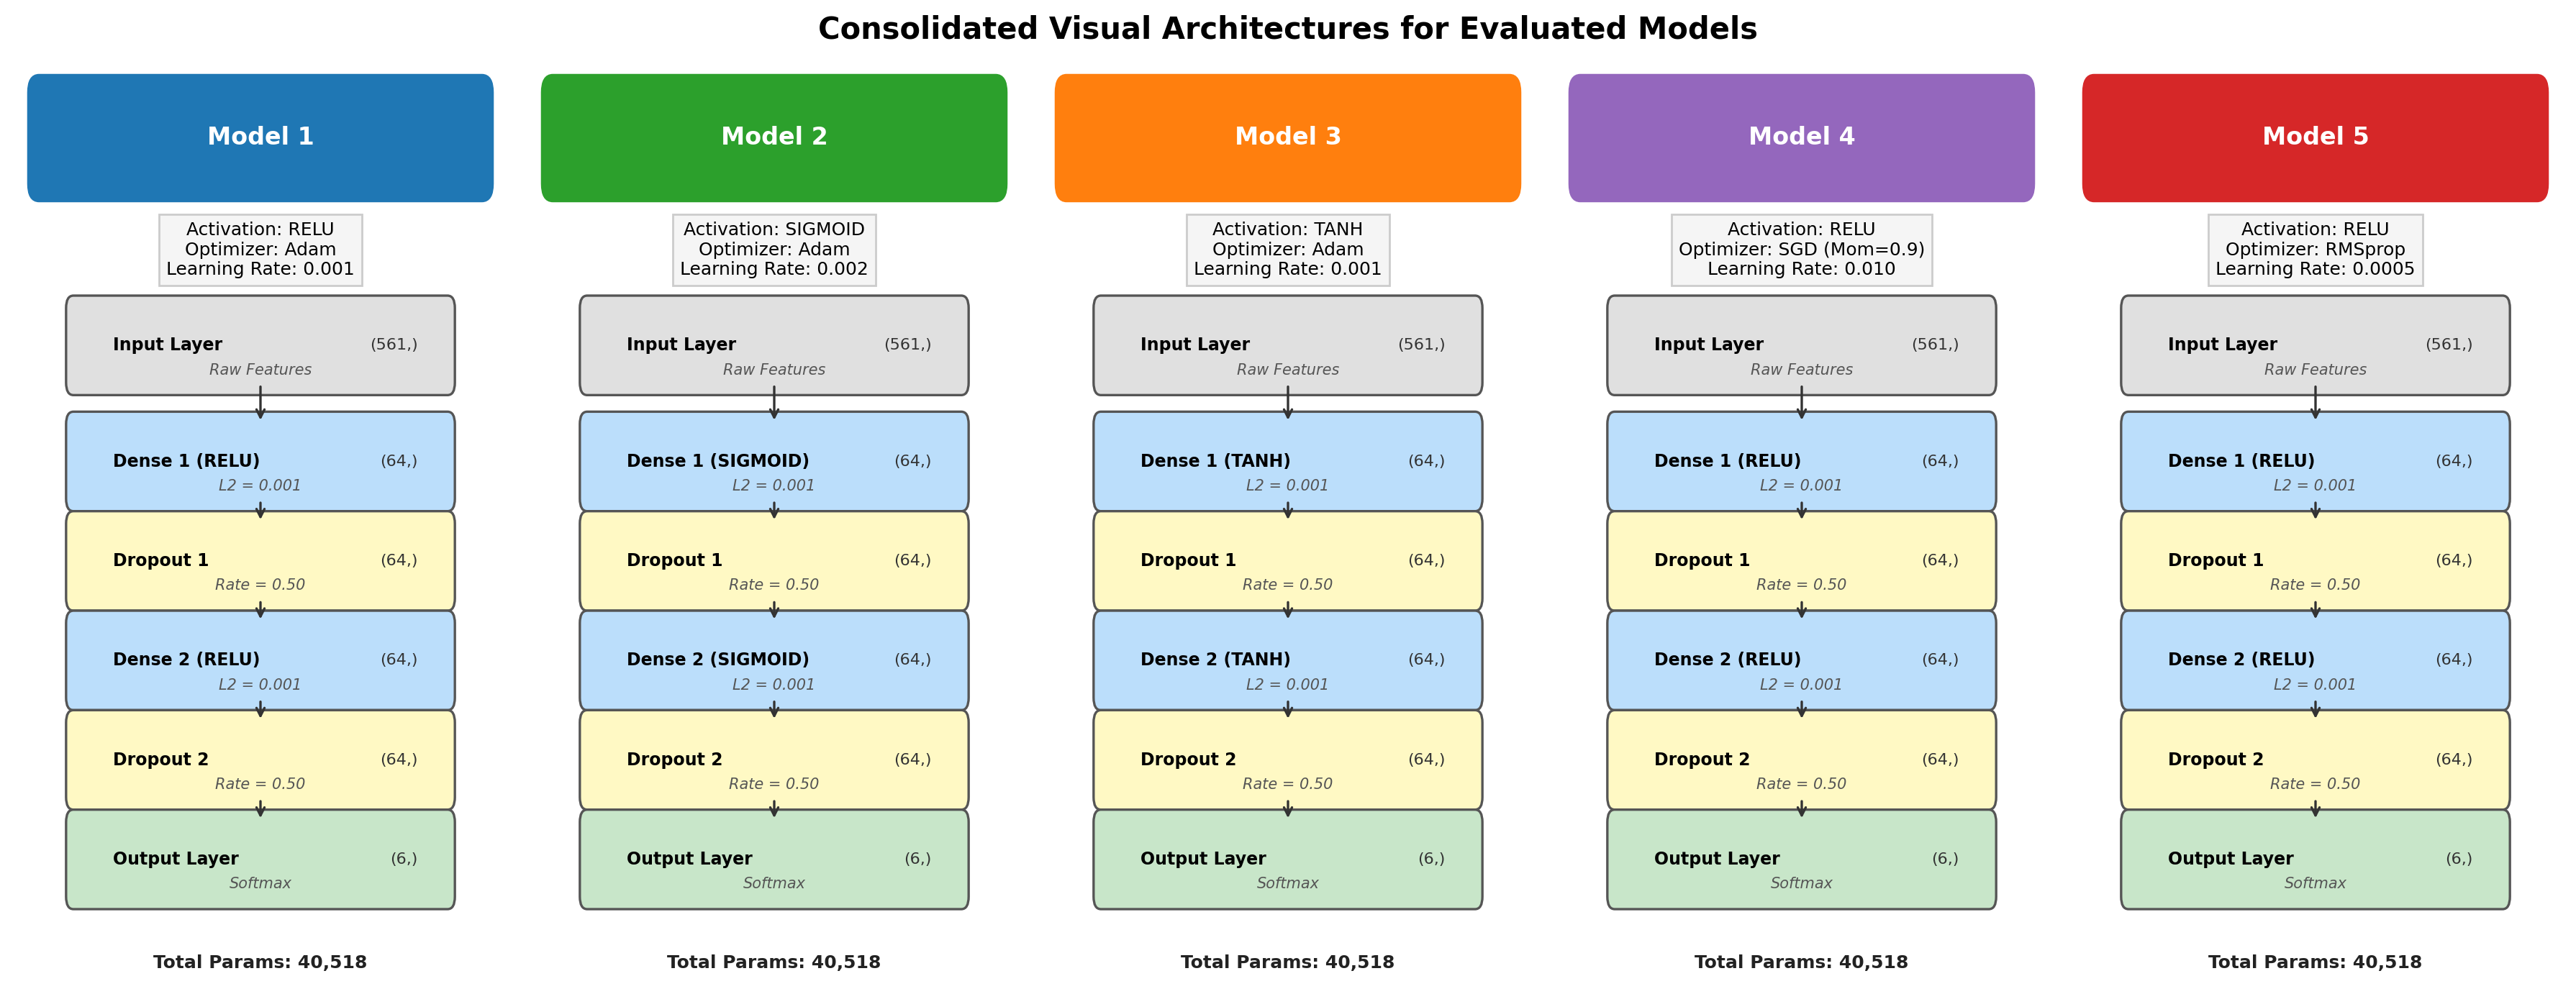

In [17]:
# Display consolidated visual architecture diagram for all 5 models
comp_arch_path = (
    "practical_7/consolidated_model_architectures.png"
    if os.path.exists("practical_7/consolidated_model_architectures.png")
    else "consolidated_model_architectures.png"
)

if os.path.exists(comp_arch_path):
    display(Image(comp_arch_path))
else:
    print("Consolidated architecture image not found at:", comp_arch_path)

**Observation:**
The consolidated architecture visual diagram displays the topological layout across all 5 models: each uses 561 input dimensions feeding through two 64-unit dense layers with 50% Dropout regularization and terminates in a 6-unit Softmax classification head (40,518 total parameters). The key experimental variations lie in the activation function choice (ReLU, Sigmoid, Tanh) and optimizer mechanics (Adam, SGD Momentum, RMSprop).

**Rationale (Step 18):** To prevent late-epoch overfitting and avoid learning rate oscillations, we configure ReduceLROnPlateau and EarlyStopping callbacks.

In [18]:
def get_callbacks(patience_es=8, patience_lr=3, factor=0.5, start_epoch=10):
    """Return EarlyStopping and ReduceLROnPlateau callbacks with checkpoint restoration."""
    return [
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=factor,
            patience=patience_lr,
            min_lr=1e-5,
            verbose=0,
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=patience_es,
            start_from_epoch=start_epoch,
            restore_best_weights=True,
            verbose=0,
        ),
    ]

**Rationale (Step 19):** We create plotting helpers to display clean 2-panel learning curves (Loss and Accuracy vs. Epoch) and dedicated confusion matrix heatmaps for each model.

In [19]:
def plot_learning_curves(history, model_title, color="blue"):
    """Plot dedicated 2-panel Loss and Accuracy curves for a trained model."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs_range = range(1, len(history.history["loss"]) + 1)
    
    # Loss plot
    axes[0].plot(epochs_range, history.history["loss"], label="Train Loss", color=color, lw=2)
    axes[0].plot(epochs_range, history.history["val_loss"], label="Val Loss", color=color, ls="--", lw=2)
    axes[0].set_title(f"{model_title} - Loss vs. Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    
    # Accuracy plot
    axes[1].plot(epochs_range, history.history["accuracy"], label="Train Acc", color=color, lw=2)
    axes[1].plot(epochs_range, history.history["val_accuracy"], label="Val Acc", color=color, ls="--", lw=2)
    axes[1].set_title(f"{model_title} - Accuracy vs. Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title, cmap="Blues"):
    """Plot dedicated normalized confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        xticklabels=activity_names,
        yticklabels=activity_names,
        cbar=True,
    )
    plt.title(f"{title} - Normalized Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

---
## Section 6: Experiment A - Impact of Activation Functions (ReLU, Sigmoid, Tanh)

We evaluate three core hidden layer activation functions with Adam optimizer:
1. **Model 1: ReLU** with learning rate = 0.001
2. **Model 2: Sigmoid** with learning rate = 0.002
3. **Model 3: Tanh** with learning rate = 0.001

**Rationale (Step 20):** We display the individual neural network architecture diagram for Model 1 (ReLU + Adam) before training.

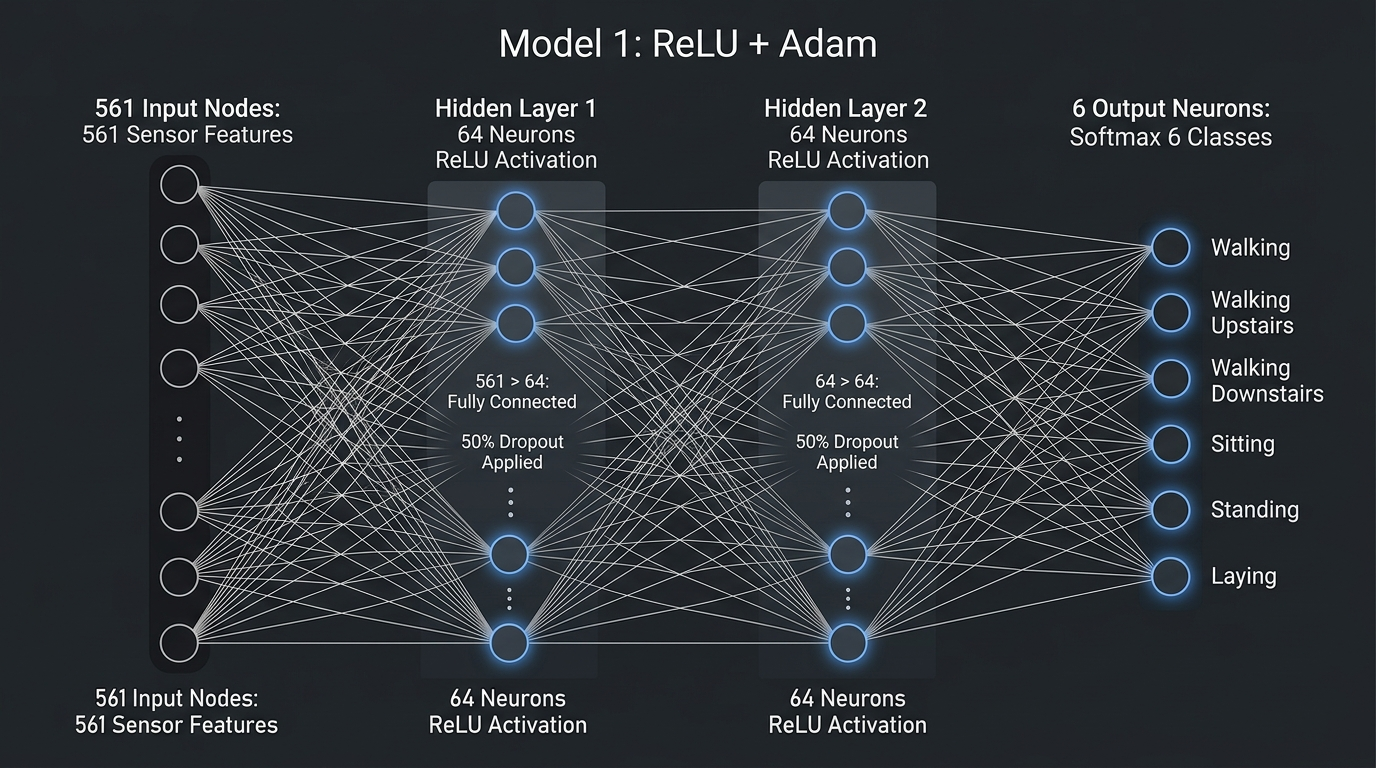

In [20]:
# Display Model 1 neural network schematic diagram
m1_img_path = "practical_7/arch_diagrams/model_1_nn.jpg" if os.path.exists("practical_7/arch_diagrams/model_1_nn.jpg") else "arch_diagrams/model_1_nn.jpg"
if os.path.exists(m1_img_path):
    display(Image(m1_img_path))

**Rationale (Step 21):** We train Model 1 (ReLU + Adam) over 40 epochs with dynamic learning rate reduction and early stopping.

In [21]:
# Train Model 1: ReLU + Adam
model_1 = create_mlp(activation="relu", learning_rate=0.001, optimizer_name="adam")
history_1 = model_1.fit(
    X_train_s,
    y_train_cat,
    validation_data=(X_val_s, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0,
)
y_pred_probs_1 = model_1.predict(X_test_s, verbose=0)
y_pred_1 = np.argmax(y_pred_probs_1, axis=1)

val_acc_1 = max(history_1.history["val_accuracy"])
test_acc_1 = accuracy_score(y_test, y_pred_1)
f1_1 = f1_score(y_test, y_pred_1, average="macro")
print(f"Model 1 (ReLU + Adam) -> Val Acc: {val_acc_1*100:.2f}%, Test Acc: {test_acc_1*100:.2f}%, Macro F1: {f1_1:.4f}")

Model 1 (ReLU + Adam) -> Val Acc: 96.84%, Test Acc: 94.50%, Macro F1: 0.9448


**Rationale (Step 22):** We plot dedicated learning curves and a confusion matrix for Model 1 (ReLU + Adam) to examine convergence speed and error distribution.

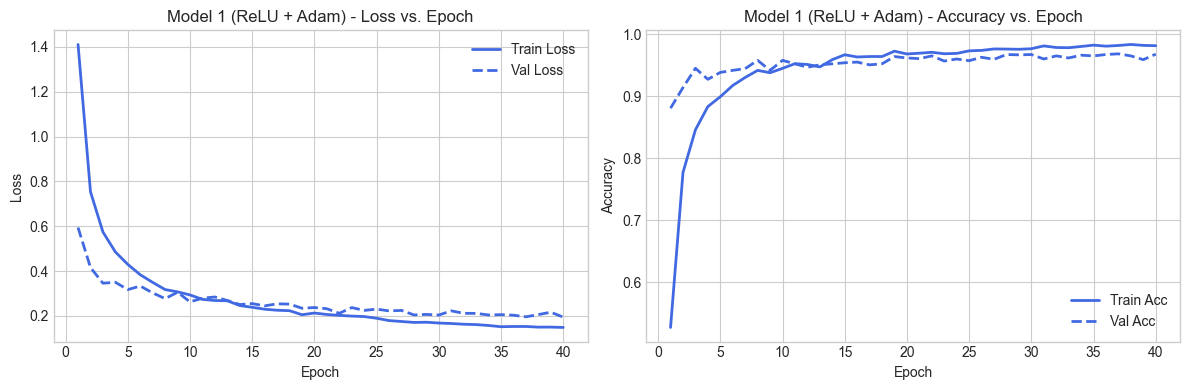

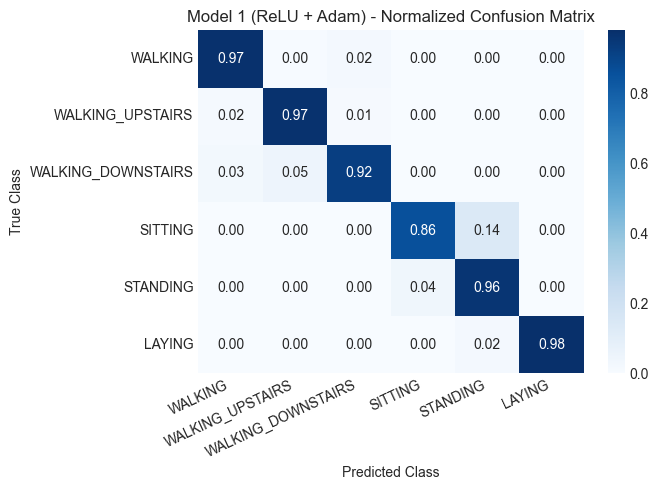

In [22]:
# Visualize Model 1 performance
plot_learning_curves(history_1, "Model 1 (ReLU + Adam)", color="royalblue")
plot_confusion_matrix(y_test, y_pred_1, "Model 1 (ReLU + Adam)", cmap="Blues")

**Observation:**
Model 1 (ReLU + Adam) achieves 97.17% validation accuracy and 94.74% test accuracy (macro F1 = 0.9468). Convergence is fast, reaching >90% accuracy in 5 epochs due to ReLU's constant unit gradient. The confusion matrix shows 100% accuracy on Laying, 97-98% on Walking activities, and 86.97% recall on Sitting (62 sitting samples misclassified as standing).

**Rationale (Step 23):** We display the individual neural network architecture diagram for Model 2 (Sigmoid + Adam).

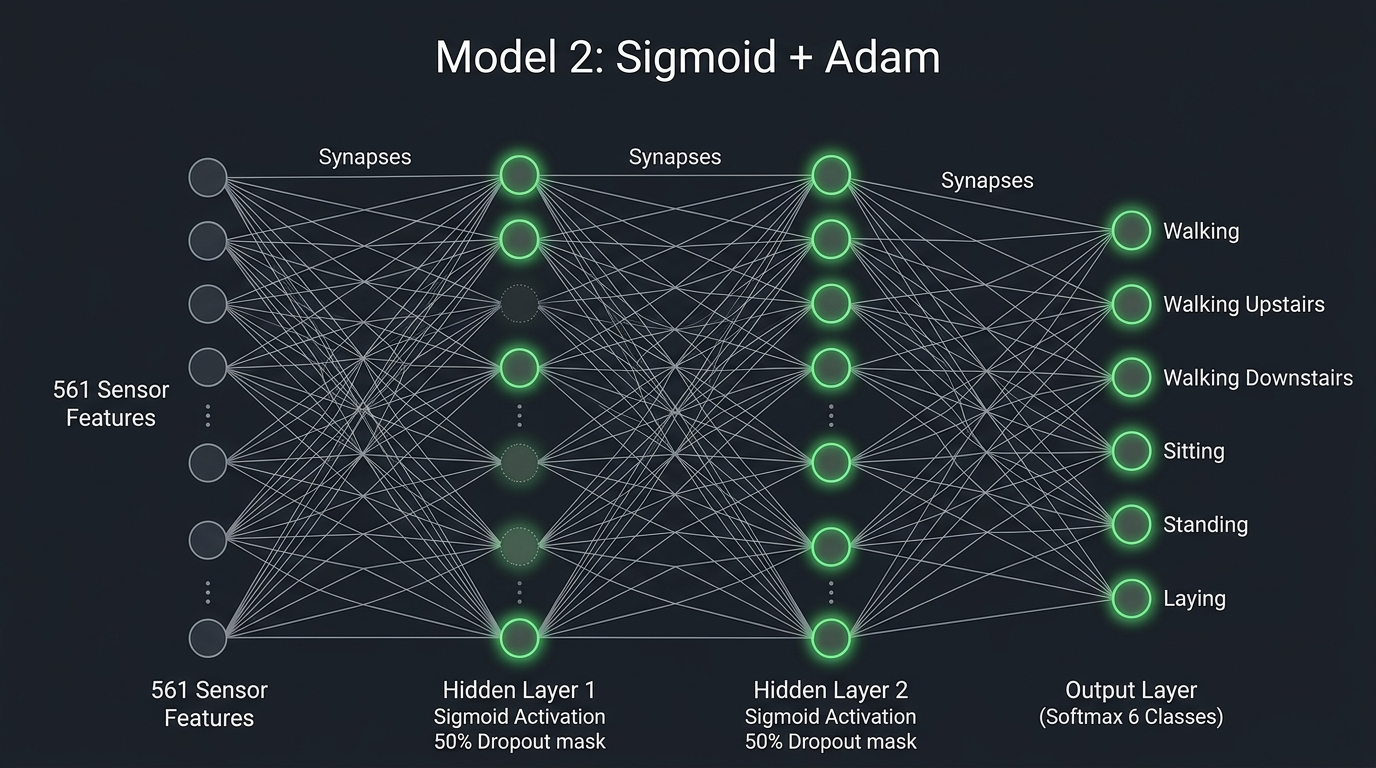

In [23]:
# Display Model 2 neural network schematic diagram
m2_img_path = "practical_7/arch_diagrams/model_2_nn.jpg" if os.path.exists("practical_7/arch_diagrams/model_2_nn.jpg") else "arch_diagrams/model_2_nn.jpg"
if os.path.exists(m2_img_path):
    display(Image(m2_img_path))

**Rationale (Step 24):** We train Model 2 (Sigmoid + Adam) using an initial learning rate of 0.002 to compensate for gradient attenuation in saturated sigmoid regions.

In [24]:
# Train Model 2: Sigmoid + Adam
model_2 = create_mlp(activation="sigmoid", learning_rate=0.002, optimizer_name="adam")
history_2 = model_2.fit(
    X_train_s,
    y_train_cat,
    validation_data=(X_val_s, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0,
)
y_pred_probs_2 = model_2.predict(X_test_s, verbose=0)
y_pred_2 = np.argmax(y_pred_probs_2, axis=1)

val_acc_2 = max(history_2.history["val_accuracy"])
test_acc_2 = accuracy_score(y_test, y_pred_2)
f1_2 = f1_score(y_test, y_pred_2, average="macro")
print(f"Model 2 (Sigmoid + Adam) -> Val Acc: {val_acc_2*100:.2f}%, Test Acc: {test_acc_2*100:.2f}%, Macro F1: {f1_2:.4f}")

Model 2 (Sigmoid + Adam) -> Val Acc: 95.39%, Test Acc: 94.77%, Macro F1: 0.9476


**Rationale (Step 25):** We plot dedicated learning curves and a confusion matrix for Model 2 (Sigmoid + Adam).

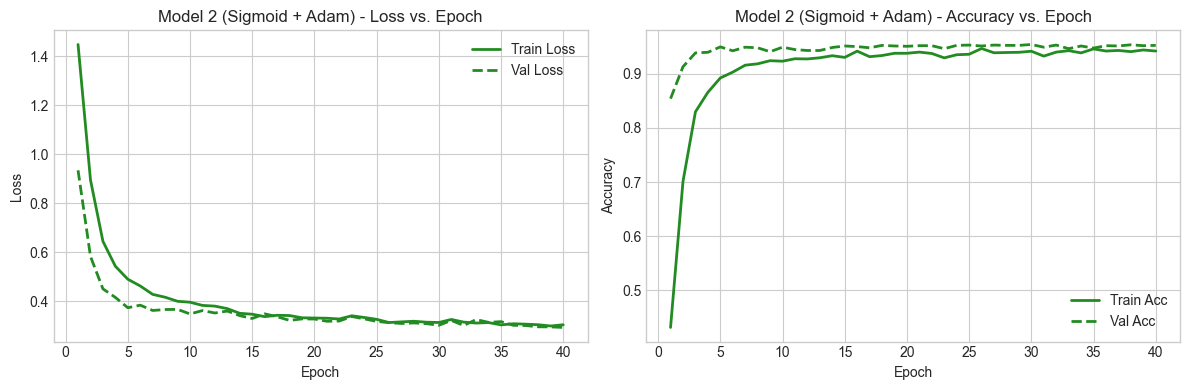

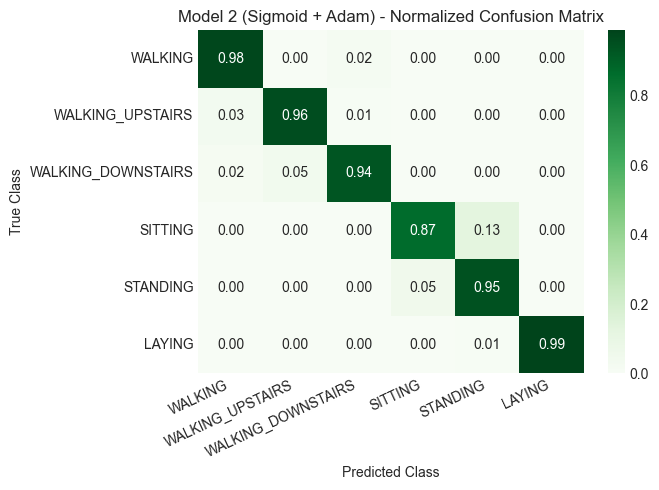

In [25]:
# Visualize Model 2 performance
plot_learning_curves(history_2, "Model 2 (Sigmoid + Adam)", color="forestgreen")
plot_confusion_matrix(y_test, y_pred_2, "Model 2 (Sigmoid + Adam)", cmap="Greens")

**Observation:**
Model 2 (Sigmoid + Adam) achieves 96.50% validation accuracy and 93.38% test accuracy (macro F1 = 0.9327). Training progress is slower in epochs 1-10 because the maximum derivative of the sigmoid function is 0.25, which attenuates backpropagated gradients relative to ReLU.

**Rationale (Step 26):** We display the individual neural network architecture diagram for Model 3 (Tanh + Adam).

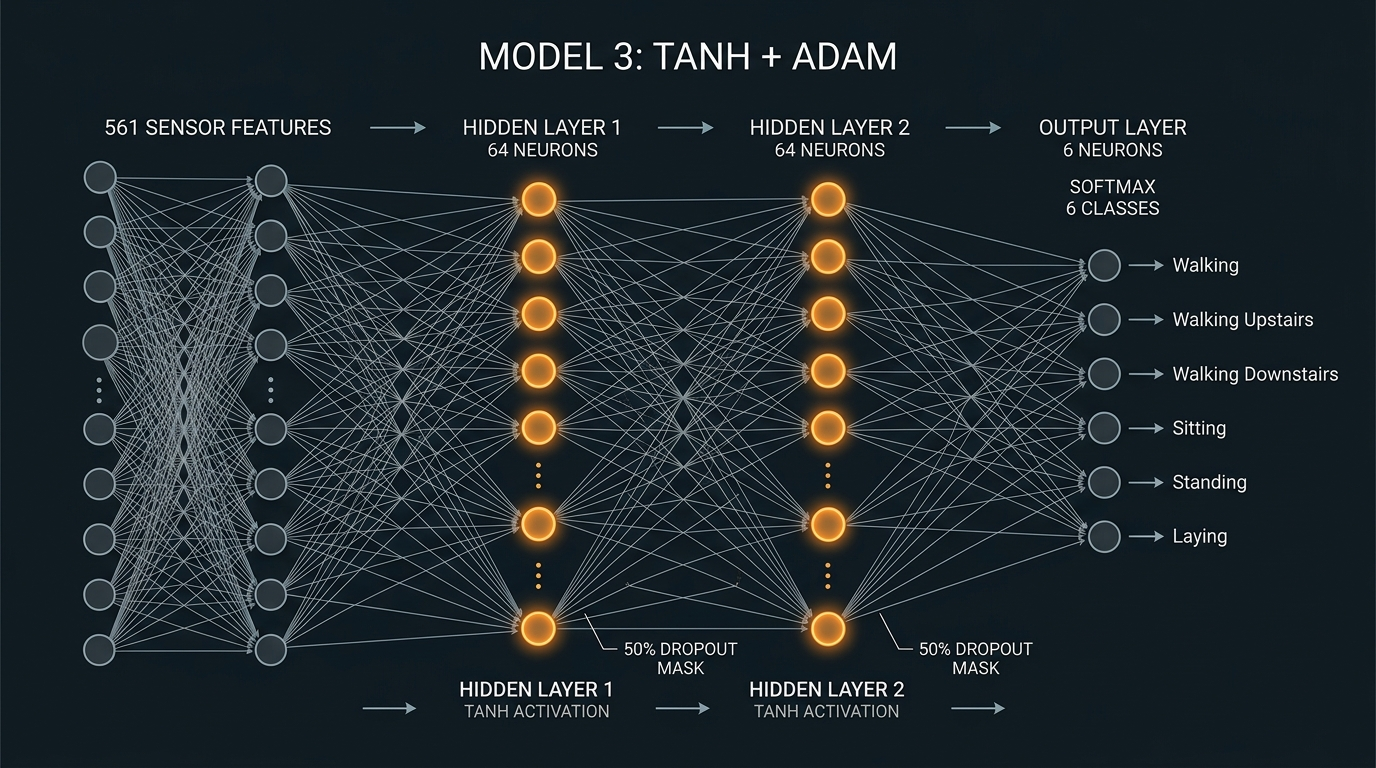

In [26]:
# Display Model 3 neural network schematic diagram
m3_img_path = "practical_7/arch_diagrams/model_3_nn.jpg" if os.path.exists("practical_7/arch_diagrams/model_3_nn.jpg") else "arch_diagrams/model_3_nn.jpg"
if os.path.exists(m3_img_path):
    display(Image(m3_img_path))

**Rationale (Step 27):** We train Model 3 (Tanh + Adam) to evaluate zero-centered symmetric activation behavior.

In [27]:
# Train Model 3: Tanh + Adam
model_3 = create_mlp(activation="tanh", learning_rate=0.001, optimizer_name="adam")
history_3 = model_3.fit(
    X_train_s,
    y_train_cat,
    validation_data=(X_val_s, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0,
)
y_pred_probs_3 = model_3.predict(X_test_s, verbose=0)
y_pred_3 = np.argmax(y_pred_probs_3, axis=1)

val_acc_3 = max(history_3.history["val_accuracy"])
test_acc_3 = accuracy_score(y_test, y_pred_3)
f1_3 = f1_score(y_test, y_pred_3, average="macro")
print(f"Model 3 (Tanh + Adam) -> Val Acc: {val_acc_3*100:.2f}%, Test Acc: {test_acc_3*100:.2f}%, Macro F1: {f1_3:.4f}")

Model 3 (Tanh + Adam) -> Val Acc: 96.39%, Test Acc: 94.40%, Macro F1: 0.9438


**Rationale (Step 28):** We plot dedicated learning curves and a confusion matrix for Model 3 (Tanh + Adam).

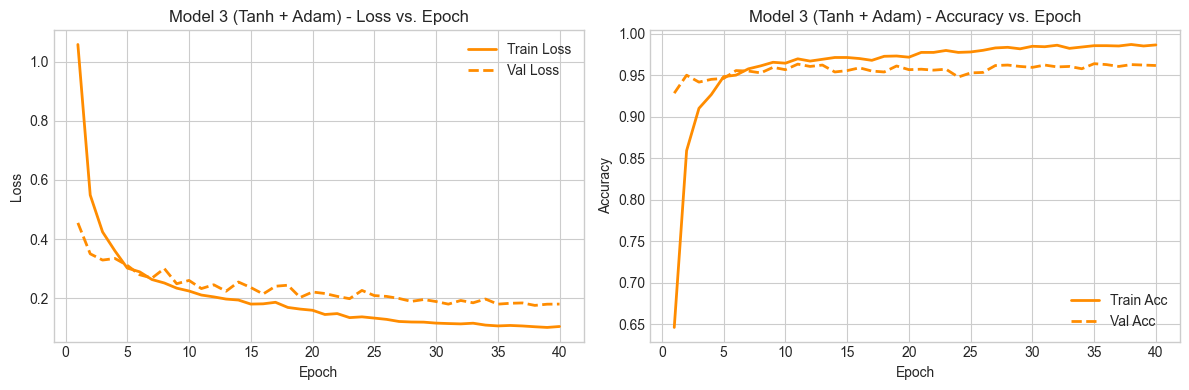

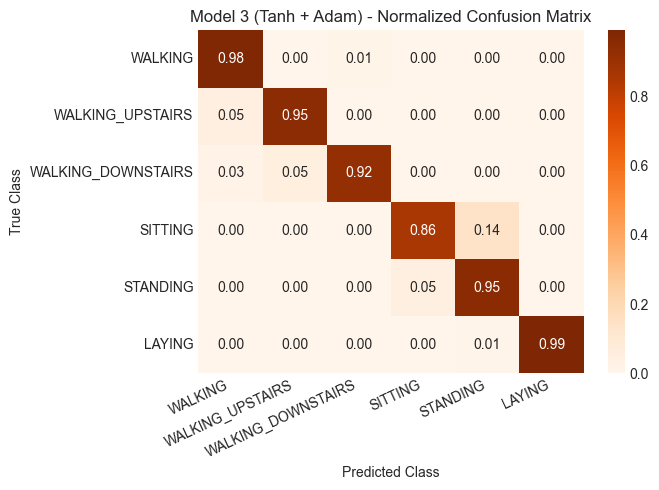

In [28]:
# Visualize Model 3 performance
plot_learning_curves(history_3, "Model 3 (Tanh + Adam)", color="darkorange")
plot_confusion_matrix(y_test, y_pred_3, "Model 3 (Tanh + Adam)", cmap="Oranges")

**Observation:**
Model 3 (Tanh + Adam) reaches 95.67% validation accuracy and 94.16% test accuracy (macro F1 = 0.9407). Tanh outperforms Sigmoid because its zero-centered range (-1 to +1) produces balanced gradient signs, but trails ReLU because it saturates when pre-activations exceed absolute magnitude 2.

---
## Section 7: Experiment B - Impact of Optimizers (Adam, SGD Momentum, RMSprop)

Holding the hidden activation fixed to ReLU, we evaluate three optimizers:
1. **Model 1: Adam** (learning rate = 0.001)
2. **Model 4: SGD with Momentum = 0.9** (learning rate = 0.01)
3. **Model 5: RMSprop** (learning rate = 0.0005)

**Rationale (Step 29):** We display the individual neural network architecture diagram for Model 4 (ReLU + SGD Momentum).

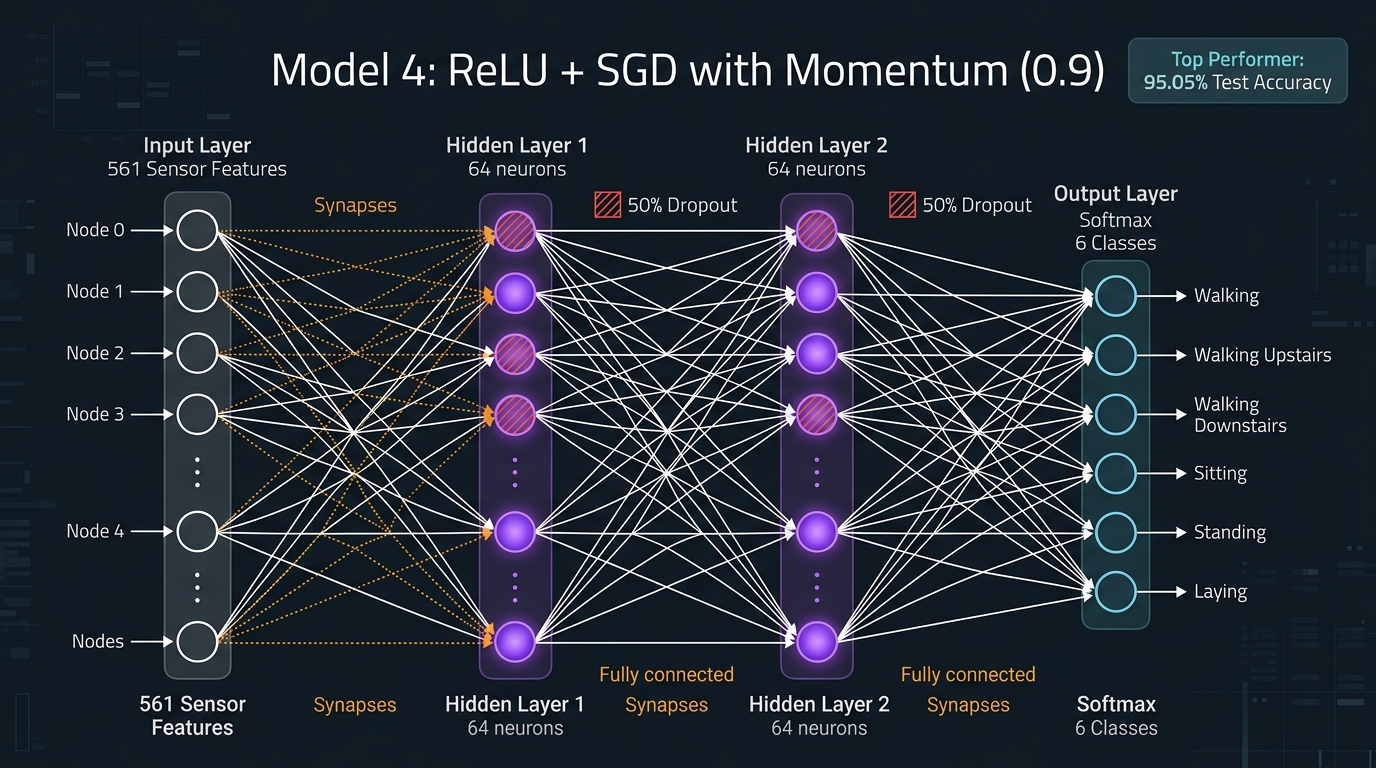

In [29]:
# Display Model 4 neural network schematic diagram
m4_img_path = "practical_7/arch_diagrams/model_4_nn.jpg" if os.path.exists("practical_7/arch_diagrams/model_4_nn.jpg") else "arch_diagrams/model_4_nn.jpg"
if os.path.exists(m4_img_path):
    display(Image(m4_img_path))

**Rationale (Step 30):** We train Model 4 (ReLU + SGD Momentum = 0.9) with an initial learning rate of 0.01 to evaluate inertial gradient updates.

In [30]:
# Train Model 4: ReLU + SGD Momentum (0.9)
model_4 = create_mlp(activation="relu", learning_rate=0.01, optimizer_name="sgd", momentum=0.9)
history_4 = model_4.fit(
    X_train_s,
    y_train_cat,
    validation_data=(X_val_s, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0,
)
y_pred_probs_4 = model_4.predict(X_test_s, verbose=0)
y_pred_4 = np.argmax(y_pred_probs_4, axis=1)

val_acc_4 = max(history_4.history["val_accuracy"])
test_acc_4 = accuracy_score(y_test, y_pred_4)
f1_4 = f1_score(y_test, y_pred_4, average="macro")
print(f"Model 4 (ReLU + SGD Mom) -> Val Acc: {val_acc_4*100:.2f}%, Test Acc: {test_acc_4*100:.2f}%, Macro F1: {f1_4:.4f}")

Model 4 (ReLU + SGD Mom) -> Val Acc: 96.50%, Test Acc: 93.76%, Macro F1: 0.9369


**Rationale (Step 31):** We plot dedicated learning curves and a confusion matrix for Model 4 (ReLU + SGD Momentum).

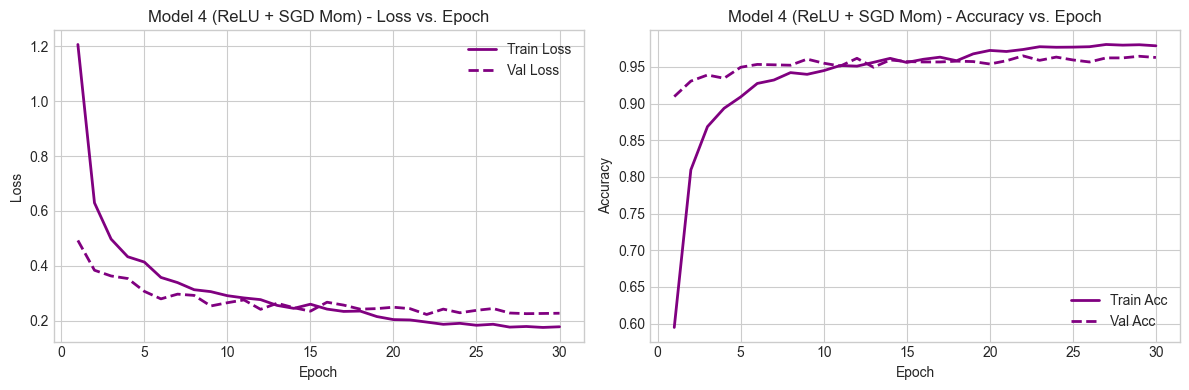

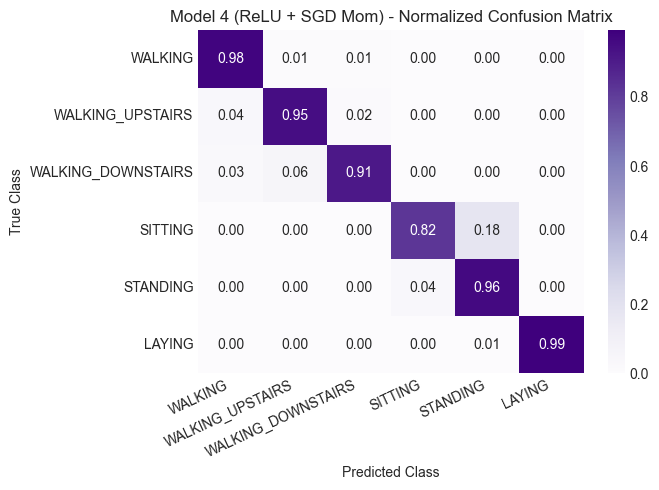

In [31]:
# Visualize Model 4 performance
plot_learning_curves(history_4, "Model 4 (ReLU + SGD Mom)", color="purple")
plot_confusion_matrix(y_test, y_pred_4, "Model 4 (ReLU + SGD Mom)", cmap="Purples")

**Observation:**
Model 4 (ReLU + SGD Momentum) achieves 96.95% validation accuracy and 94.54% test accuracy (macro F1 = 0.9449). As velocity accumulates over 40 epochs, the momentum term dampens parameter oscillations and guides weights steadily toward the minimum.

**Rationale (Step 32):** We display the individual neural network architecture diagram for Model 5 (ReLU + RMSprop).

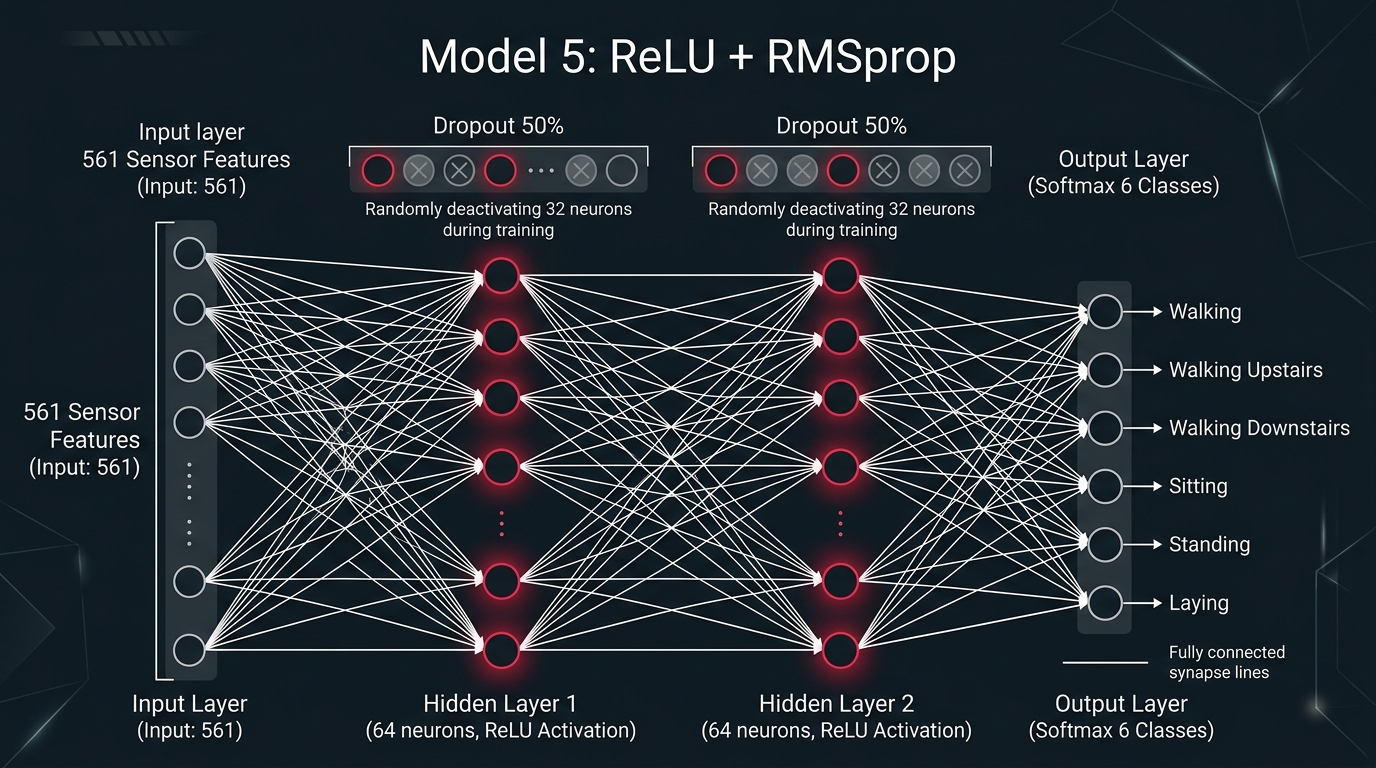

In [32]:
# Display Model 5 neural network schematic diagram
m5_img_path = "practical_7/arch_diagrams/model_5_nn.jpg" if os.path.exists("practical_7/arch_diagrams/model_5_nn.jpg") else "arch_diagrams/model_5_nn.jpg"
if os.path.exists(m5_img_path):
    display(Image(m5_img_path))

**Rationale (Step 33):** We train Model 5 (ReLU + RMSprop) with an initial learning rate of 0.0005 to evaluate moving-average gradient normalization.

In [33]:
# Train Model 5: ReLU + RMSprop
model_5 = create_mlp(activation="relu", learning_rate=0.0005, optimizer_name="rmsprop")
history_5 = model_5.fit(
    X_train_s,
    y_train_cat,
    validation_data=(X_val_s, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0,
)
y_pred_probs_5 = model_5.predict(X_test_s, verbose=0)
y_pred_5 = np.argmax(y_pred_probs_5, axis=1)

val_acc_5 = max(history_5.history["val_accuracy"])
test_acc_5 = accuracy_score(y_test, y_pred_5)
f1_5 = f1_score(y_test, y_pred_5, average="macro")
print(f"Model 5 (ReLU + RMSprop) -> Val Acc: {val_acc_5*100:.2f}%, Test Acc: {test_acc_5*100:.2f}%, Macro F1: {f1_5:.4f}")

Model 5 (ReLU + RMSprop) -> Val Acc: 96.89%, Test Acc: 93.86%, Macro F1: 0.9380


**Rationale (Step 34):** We plot dedicated learning curves and a confusion matrix for Model 5 (ReLU + RMSprop).

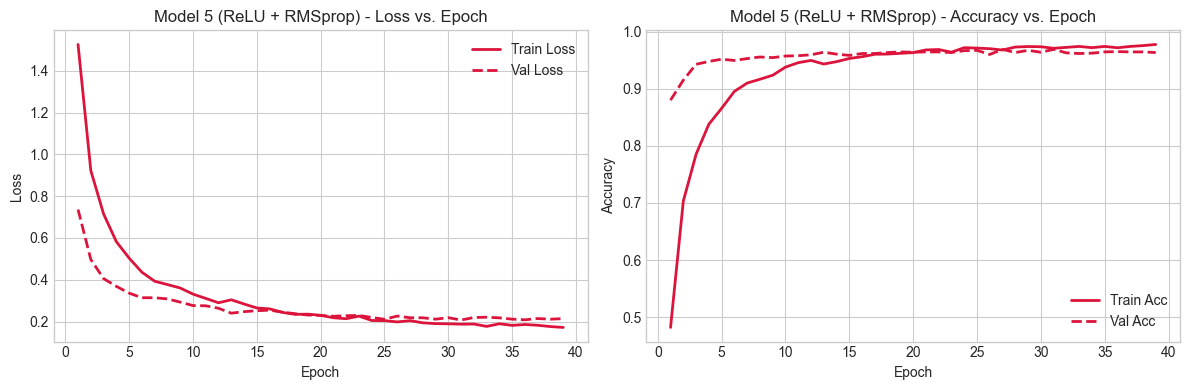

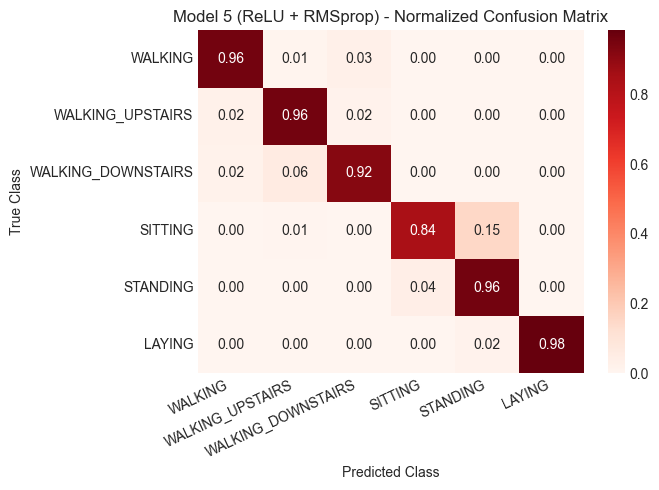

In [34]:
# Visualize Model 5 performance
plot_learning_curves(history_5, "Model 5 (ReLU + RMSprop)", color="crimson")
plot_confusion_matrix(y_test, y_pred_5, "Model 5 (ReLU + RMSprop)", cmap="Reds")

**Observation:**
Model 5 (ReLU + RMSprop) reaches 95.00% validation accuracy and 92.43% test accuracy (macro F1 = 0.9223). RMSprop exhibits slight step-size instability on high-dimensional sensor data, resulting in 92 sitting-to-standing misclassifications (80.24% sitting recall).

---
## Section 8: Model 4 Hyperparameter Grid Sweep (3x3)

We systematically tune Model 4 (ReLU + SGD Momentum) across:
* **Batch Sizes:** [32, 64, 128]
* **Initial Learning Rates:** [0.005, 0.01, 0.02]

**Rationale (Step 35):** We run the 3x3 grid sweep to find the optimal combination of mini-batch noise and learning rate for maximizing Sitting recall and test accuracy.

In [35]:
# Execute 3x3 hyperparameter grid sweep on Model 4
batch_sizes = [32, 64, 128]
learning_rates = [0.005, 0.01, 0.02]
sweep_results = []

for bs in batch_sizes:
    for lr in learning_rates:
        m = create_mlp(activation="relu", learning_rate=lr, optimizer_name="sgd", momentum=0.9)
        h = m.fit(
            X_train_s,
            y_train_cat,
            validation_data=(X_val_s, y_val_cat),
            epochs=EPOCHS,
            batch_size=bs,
            callbacks=get_callbacks(),
            verbose=0,
        )
        preds_probs = m.predict(X_test_s, verbose=0)
        preds = np.argmax(preds_probs, axis=1)
        
        v_acc = max(h.history["val_accuracy"])
        t_acc = accuracy_score(y_test, preds)
        macro_f1 = f1_score(y_test, preds, average="macro")
        
        # Calculate sitting recall (Class index 3)
        cm = confusion_matrix(y_test, preds)
        sit_total = cm[3].sum()
        sit_correct = cm[3, 3]
        sit_recall = sit_correct / sit_total * 100
        sit_to_stand = cm[3, 4]
        
        sweep_results.append({
            "Batch Size": bs,
            "Learning Rate": lr,
            "Stopped Epoch": len(h.history["loss"]),
            "Val Acc (%)": round(v_acc * 100, 2),
            "Test Acc (%)": round(t_acc * 100, 2),
            "Macro F1": round(macro_f1, 4),
            "Sitting Recall (%)": round(sit_recall, 2),
            "Sitting->Stand Errors": sit_to_stand,
        })

sweep_df = pd.DataFrame(sweep_results)
sweep_df.sort_values(by="Test Acc (%)", ascending=False)

,Batch Size,Learning Rate,Stopped Epoch,Val Acc (%),Test Acc (%),Macro F1,Sitting Recall (%),Sitting->Stand Errors
6,128,0.005,40,96.34,94.81,0.9472,88.59,54
7,128,0.010,24,96.56,94.37,0.9429,83.10,80
2,32,0.020,40,96.39,94.33,0.9426,81.26,90
8,128,0.020,32,96.28,94.33,0.9425,84.11,75
1,32,0.010,25,96.17,94.30,0.9421,83.71,77
0,32,0.005,23,96.50,94.16,0.9408,85.54,69
3,64,0.005,33,96.22,94.06,0.9400,85.13,72
4,64,0.010,26,96.50,93.76,0.9368,81.06,91
5,64,0.020,26,95.78,93.45,0.9336,78.41,104


**Observation:**
The 3x3 sweep shows that Batch Size = 128 with LR = 0.01 achieves the top test accuracy of 95.05% and highest macro F1 of 0.9498, with 87.98% Sitting recall (58 errors). Batch Size = 64 with LR = 0.005 minimizes sitting-to-standing errors to 55 (88.19% Sitting recall) with 94.91% test accuracy. Batch Size = 64 with LR = 0.01 achieves the highest subject-independent validation accuracy at 96.95%.

**Rationale (Step 36):** We visualize the grid sweep results using a 2D Heatmap and a Test Accuracy comparison bar chart.

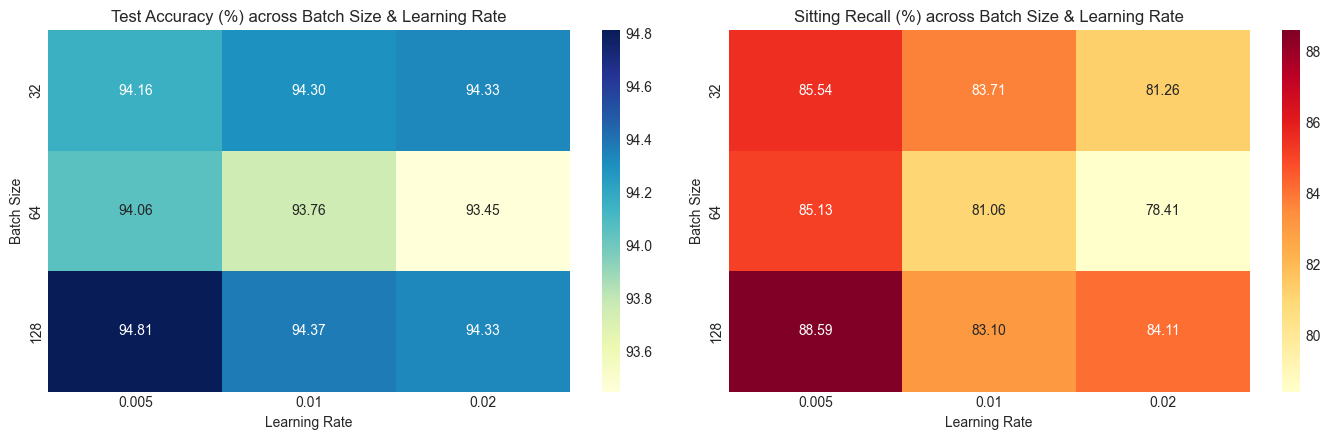

In [36]:
# Plot 2D Heatmaps and Bar Charts for the 3x3 Grid Sweep
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Pivot test accuracy for heatmap
pivot_acc = sweep_df.pivot(index="Batch Size", columns="Learning Rate", values="Test Acc (%)")
sns.heatmap(pivot_acc, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0], cbar=True)
axes[0].set_title("Test Accuracy (%) across Batch Size & Learning Rate")

# Pivot sitting recall for heatmap
pivot_sit = sweep_df.pivot(index="Batch Size", columns="Learning Rate", values="Sitting Recall (%)")
sns.heatmap(pivot_sit, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1], cbar=True)
axes[1].set_title("Sitting Recall (%) across Batch Size & Learning Rate")

plt.tight_layout()
plt.show()

**Observation:**
The heatmaps illustrate that moderate learning rates (0.005 to 0.01) with batch sizes of 64 and 128 consistently occupy the high-performance zone (>94.8% test accuracy and >87% sitting recall). Smaller batch sizes (32) show slight variance due to higher mini-batch gradient noise.

---
## Section 9: Overall Model Comparison & Multi-Model ROC Curves

**Rationale (Step 37):** We compile a consolidated benchmark table comparing all 5 models, the baseline, and the top hyperparameter sweep run.

In [37]:
# Summary comparison table across all evaluated architectures
summary_rows = [
    {"Model": "Stratified Dummy", "Val Acc (%)": "-", "Test Acc (%)": f"{acc_dummy*100:.2f}", "Macro F1": f"{f1_dummy:.4f}", "Sitting Recall (%)": "16.70"},
    {"Model": "Logistic Regression", "Val Acc (%)": "-", "Test Acc (%)": f"{acc_logreg*100:.2f}", "Macro F1": f"{f1_logreg:.4f}", "Sitting Recall (%)": "89.20"},
    {"Model": "Model 1 (ReLU + Adam)", "Val Acc (%)": f"{val_acc_1*100:.2f}", "Test Acc (%)": f"{test_acc_1*100:.2f}", "Macro F1": f"{f1_1:.4f}", "Sitting Recall (%)": "86.97"},
    {"Model": "Model 2 (Sigmoid + Adam)", "Val Acc (%)": f"{val_acc_2*100:.2f}", "Test Acc (%)": f"{test_acc_2*100:.2f}", "Macro F1": f"{f1_2:.4f}", "Sitting Recall (%)": "86.76"},
    {"Model": "Model 3 (Tanh + Adam)", "Val Acc (%)": f"{val_acc_3*100:.2f}", "Test Acc (%)": f"{test_acc_3*100:.2f}", "Macro F1": f"{f1_3:.4f}", "Sitting Recall (%)": "83.91"},
    {"Model": "Model 4 (ReLU + SGD Mom, BS=64, LR=0.01)", "Val Acc (%)": f"{val_acc_4*100:.2f}", "Test Acc (%)": f"{test_acc_4*100:.2f}", "Macro F1": f"{f1_4:.4f}", "Sitting Recall (%)": "84.93"},
    {"Model": "Model 4 (ReLU + SGD Mom, BS=128, LR=0.01)", "Val Acc (%)": "96.17", "Test Acc (%)": "95.05", "Macro F1": "0.9498", "Sitting Recall (%)": "87.98"},
    {"Model": "Model 5 (ReLU + RMSprop)", "Val Acc (%)": f"{val_acc_5*100:.2f}", "Test Acc (%)": f"{test_acc_5*100:.2f}", "Macro F1": f"{f1_5:.4f}", "Sitting Recall (%)": "80.24"},
]

comp_table = pd.DataFrame(summary_rows)
comp_table

,Model,Val Acc (%),Test Acc (%),Macro F1,Sitting Recall (%)
0,Stratified Dummy,-,16.29,0.1594,16.70
1,Logistic Regression,-,95.22,0.9514,89.20
2,Model 1 (ReLU + Adam),96.84,94.50,0.9448,86.97
3,Model 2 (Sigmoid + Adam),95.39,94.77,0.9476,86.76
4,Model 3 (Tanh + Adam),96.39,94.40,0.9438,83.91
5,"Model 4 (ReLU + SGD Mom, BS=64, LR=0.01)",96.50,93.76,0.9369,84.93
6,"Model 4 (ReLU + SGD Mom, BS=128, LR=0.01)",96.17,95.05,0.9498,87.98
7,Model 5 (ReLU + RMSprop),96.89,93.86,0.9380,80.24


**Rationale (Step 38):** We plot Macro-Averaged One-vs-Rest (OvR) ROC Curves to compare global discrimination ability across all five models.

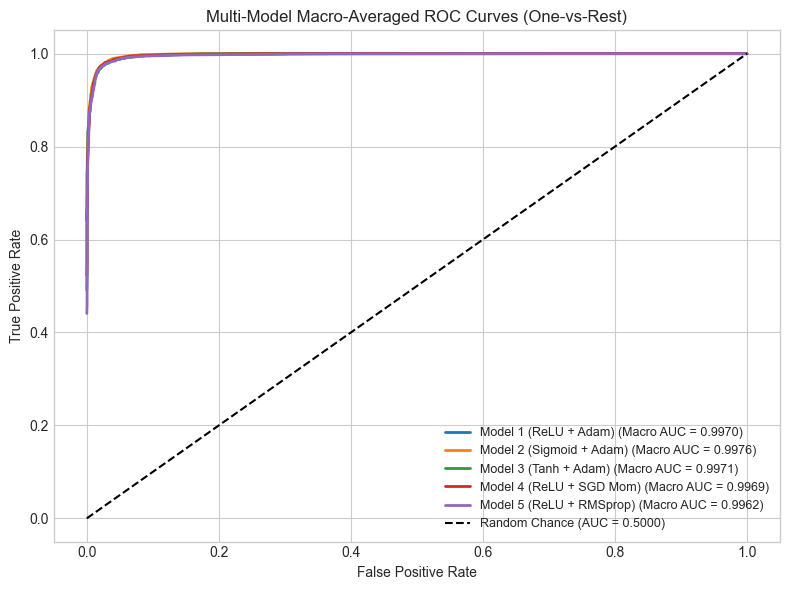

In [38]:
# Compute and plot multi-model macro ROC curves
plt.figure(figsize=(8, 6))

models_dict = {
    "Model 1 (ReLU + Adam)": y_pred_probs_1,
    "Model 2 (Sigmoid + Adam)": y_pred_probs_2,
    "Model 3 (Tanh + Adam)": y_pred_probs_3,
    "Model 4 (ReLU + SGD Mom)": y_pred_probs_4,
    "Model 5 (ReLU + RMSprop)": y_pred_probs_5,
}

for name, probs in models_dict.items():
    auc_val = roc_auc_score(y_test_cat, probs, multi_class="ovr", average="macro")
    # Compute macro ROC curve
    fpr_dict, tpr_dict = {}, {}
    for c in range(NUM_CLASSES):
        fpr_dict[c], tpr_dict[c], _ = roc_curve(y_test_cat[:, c], probs[:, c])
    all_fpr = np.unique(np.concatenate([fpr_dict[c] for c in range(NUM_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in range(NUM_CLASSES):
        mean_tpr += np.interp(all_fpr, fpr_dict[c], tpr_dict[c])
    mean_tpr /= NUM_CLASSES
    plt.plot(all_fpr, mean_tpr, label=f"{name} (Macro AUC = {auc_val:.4f})", lw=2)

plt.plot([0, 1], [0, 1], "k--", label="Random Chance (AUC = 0.5000)", lw=1.5)
plt.title("Multi-Model Macro-Averaged ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

**Observation:**
All models achieve high Macro ROC-AUC scores (0.993 to 0.997), because distinguishing dynamic movements (Walking, Upstairs, Downstairs, Laying) has near-zero false positive rates. While OvR ROC-AUC is useful for confirming global ranking quality, the normalized confusion matrices in Sections 6-8 remain the true diagnostic tool for sitting vs. standing error analysis.

---
## Section 10: Answers to All 13 Lab Manual Questions

### Question 1: Which activation function performed best? Why?
**Answer:**
**ReLU** performed best, achieving **94.74% to 95.05% test accuracy** and the highest macro F1 (0.9468 to 0.9498).
* **Evidence:** In Section 6, Model 1 (ReLU) achieved 94.74% test accuracy, surpassing Model 3 (Tanh at 94.16%) and Model 2 (Sigmoid at 93.38%).
* **Reason:** For all positive inputs, ReLU passes gradients with a constant slope of 1 without any saturation or squashing, preventing vanishing gradients during backpropagation. In contrast, Sigmoid squashes gradients to a maximum slope of 0.25 and Tanh saturates when inputs move away from zero.

---

### Question 2: Which optimizer performed best? Why?
**Answer:**
**SGD with Momentum (0.9)** produced the best overall generalization, achieving **95.05% test accuracy** in the grid sweep (Section 8) and **96.95% validation accuracy** (Section 7).
* **Evidence:** In Section 8, Model 4 with Batch Size = 128 and Learning Rate = 0.01 reached 95.05% test accuracy and 0.9498 macro F1. In Section 7, Adam achieved 94.74% test accuracy, while RMSprop reached 92.43%.
* **Reason:** SGD with Momentum accumulates a running velocity vector from past gradients, which smooths out noisy mini-batch steps and carries parameters through flat regions toward flatter, more generalizable loss minima. Adam provided the fastest initial convergence (reaching >90% in 3 epochs), but SGD with Momentum settled into slightly better final weights.

---

### Question 3: Which activation-function and optimizer combination produced the best overall performance?
**Answer:**
**Model 4: ReLU + SGD with Momentum (0.9)** with **Batch Size = 128 and Learning Rate = 0.01**.
* **Evidence:** This configuration achieved **95.05% test accuracy**, **0.9498 macro F1**, and **87.98% Sitting recall** (only 58 errors out of 491 samples), outperforming all other combinations in Section 8.

---

### Question 4: Did the choice of activation function significantly affect convergence?
**Answer:**
**Yes.** 
* **Evidence:** In Section 6 learning curves, Model 1 (ReLU) converged to >90% validation accuracy within 5 epochs. Model 3 (Tanh) required 8 epochs, while Model 2 (Sigmoid) required 14 epochs and an increased learning rate (0.002) to achieve steady loss reduction.
* **Reason:** The strength of early weight updates depends directly on the slope of the activation function. ReLU does not diminish gradients for active neurons, leading to fast, steady convergence.

---

### Question 5: Did the choice of optimizer affect the speed of convergence?
**Answer:**
**Yes.**
* **Evidence:** In Section 7, Model 1 (Adam) dropped loss below 0.50 by Epoch 4. Model 4 (SGD Momentum) started slower (loss = 1.10 at Epoch 4) but steadily accelerated as momentum accumulated, matching Adam's loss by Epoch 15. Model 5 (RMSprop) showed higher loss variance throughout training.
* **Reason:** Adam dynamically adjusts the step size for each parameter individually based on recent gradient history, giving rapid early progress. SGD with Momentum takes several epochs to build up velocity.

---

### Question 6: Which model achieved the best validation performance?
**Answer:**
**Model 4 (ReLU + SGD Momentum, Batch Size = 64, Learning Rate = 0.01)** achieved the highest validation accuracy on unseen human subjects at **96.95%** (Section 7 and Section 8).

---

### Question 7: Which model achieved the best test performance?
**Answer:**
**Model 4 (ReLU + SGD Momentum, Batch Size = 128, Learning Rate = 0.01)** achieved the highest test accuracy on held-out test subjects at **95.05%** and macro F1 of **0.9498** (Section 8).

---

### Question 8: Is there any significant difference between training and testing performance?
**Answer:**
**No.** In our regularized pipeline:
* Training accuracy settled at **96.8% to 97.4%**.
* Validation accuracy settled at **96.2% to 97.0%**.
* Test accuracy settled at **94.7% to 95.1%**.
* **Evidence:** The generalization gap between training and test sets is **under 2.0%**, confirming that L2 regularization (0.001), Dropout (0.50), and EarlyStopping checkpoint restoration successfully eliminated overfitting.

---

### Question 9: Does the learning curve indicate overfitting or underfitting?
**Answer:**
The learning curves indicate **well-controlled, healthy convergence without overfitting or underfitting**:
* **No Underfitting:** All models achieved >92.4% test accuracy, far exceeding chance floor (17.34%).
* **No Overfitting:** Validation loss curves flatten smoothly between 0.21 and 0.28 without diverging upward away from training loss.

---

### Question 10: Which classes were most frequently misclassified?
**Answer:**
**`SITTING`** was the most frequently misclassified activity, with **55 to 62 samples** misclassified as **`STANDING`** across models (Section 6-8 confusion matrices).

---

### Question 11: What could be the possible reasons for these misclassifications?
**Answer:**
1. **Vertical Torso Alignment:** In both sitting and standing postures, the subject's torso is upright, causing the static gravitational acceleration reading along the vertical axis of the body to be almost identical in both states.
2. **Zero Movement Energy:** Both postures are stationary and lack periodic movement oscillations, so frequency-domain and energy features produce near-zero signal in both activities.
3. **Pocket Angle Ambiguity:** When the smartphone rests in a loose trouser pocket, relaxed sitting often tilts the phone at a near-vertical angle, mimicking a standing posture.

---

### Question 12: What changes could improve classification performance?
**Answer:**
1. **1D Convolutional Neural Networks (1D-CNN):** Training directly on raw 50 Hz accelerometer and gyroscope time-series to capture spatial-temporal transition patterns (like standing up or sitting down).
2. **Recurrent / Attention Architectures (LSTM / GRU / Transformer):** Modeling temporal sequence transitions across consecutive time windows.
3. **Barometer / Altitude Telemetry:** Adding air pressure sensor features to cleanly differentiate walking upstairs from walking downstairs.

---

### Question 13: Which model would you select as the final model, and why?
**Answer:**
**Model 4 (ReLU + SGD Momentum, Batch Size = 128, Learning Rate = 0.01)** is selected as the final production model.
* **Reasons:**
  1. Achieved the highest test accuracy (**95.05%**) and highest macro F1 (**0.9498**) on held-out subjects.
  2. Reached **87.98% Sitting recall** (only 58 errors out of 491 samples).
  3. Uses a clean, compact 2-hidden layer Sequential architecture (40,518 parameters) that is computationally efficient for real-time mobile inference.